# Exercitii

### **Exercitiul 1**

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch import nn

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
def synthetic_data(w, b):
    """Generate y = Xw + b + noise."""
    X = torch.arange(-3., 3., .1).reshape(-1, 1)
    y = X @ w + b
    y += torch.normal(0, 0.1, y.shape)
    return X, y.reshape(-1, 1)

In [ ]:
true_w = torch.tensor([1.])
true_b = -1.
features, labels = synthetic_data(true_w, true_b)

In [ ]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [ ]:
net = nn.Sequential(nn.Linear(1, 1))

In [ ]:
net[0].weight.data.fill_(1)
net[0].bias.data.fill_(1)

tensor([1.])

In [ ]:
batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [ ]:
def mse_loss(y_true, y_pred):
  return torch.mean((y_pred-y_true)**2)

In [ ]:
optimizer = torch.optim.SGD(net.parameters(), lr=0.05)

In [ ]:
num_epochs = 20
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = mse_loss(net(X), y)
        l.backward()
        net[0].weight.data = net[0].weight.data - 0.05 * net[0].weight.grad.data
        net[0].bias.data = net[0].bias.data - 0.05 * net[0].bias.grad.data
        net[0].weight.grad.data.zero_()
        net[0].bias.grad.data.zero_()
    l = mse_loss(net(features), labels)
    print(f'Epoch {epoch + 1}, Loss {l:f}')

Epoch 1, Loss 0.010004
Epoch 2, Loss 0.009945
Epoch 3, Loss 0.009949
Epoch 4, Loss 0.009998
Epoch 5, Loss 0.010143
Epoch 6, Loss 0.010002
Epoch 7, Loss 0.010117
Epoch 8, Loss 0.009954
Epoch 9, Loss 0.010042
Epoch 10, Loss 0.009949
Epoch 11, Loss 0.009991
Epoch 12, Loss 0.009948
Epoch 13, Loss 0.009970
Epoch 14, Loss 0.009956
Epoch 15, Loss 0.010008
Epoch 16, Loss 0.009956
Epoch 17, Loss 0.009949
Epoch 18, Loss 0.010135
Epoch 19, Loss 0.010009
Epoch 20, Loss 0.009948


In [ ]:
net[0].weight.data

tensor([[0.9915]])

In [ ]:
net[0].bias.data

tensor([-1.0649])

In [ ]:
w = net[0].weight.data
print('Error in estimating w:', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('Error in estimating b:', true_b - b)

Error in estimating w: tensor([0.0085])
Error in estimating b: tensor([0.0649])


# Exercitiul 2

In [ ]:
import torchvision
from torchvision import transforms

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.MNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.MNIST(
    root="../data", train=False, transform=trans, download=True)

100%|██████████| 9912422/9912422 [00:00<00:00, 91509134.79it/s]


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 21550559.30it/s]

Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw




100%|██████████| 1648877/1648877 [00:00<00:00, 25937867.39it/s]


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 13987172.37it/s]

Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw



In [ ]:
def get_fashion_mnist_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['0', '1', '2', '3', '4',
                   '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [ ]:
mnist_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.MNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.MNIST(
        root="../data", train=False, transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [30000, 30000], # 30000 validation and 30000 train
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
batch_size = 100 # BATCH SIZE 100
train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size)

In [ ]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

In [ ]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.ones_(m.weight)

net.apply(init_weights)  # Set weigths to 1

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

In [ ]:
loss = nn.CrossEntropyLoss() # Cross entropy Loss

In [ ]:
lr = 0.15
optimizer = torch.optim.SGD(net.parameters(), lr=lr) # SGD with lr 0.15

In [ ]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
num_epochs = 15
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Epoch 1, Train loss 0.58, Train accuracy 86.06, Validation loss 0.41, Validation accuracy 89.06
Epoch 2, Train loss 0.37, Train accuracy 89.82, Validation loss 0.37, Validation accuracy 89.98
Epoch 3, Train loss 0.34, Train accuracy 90.62, Validation loss 0.35, Validation accuracy 90.37
Epoch 4, Train loss 0.32, Train accuracy 91.01, Validation loss 0.34, Validation accuracy 90.47
Epoch 5, Train loss 0.31, Train accuracy 91.32, Validation loss 0.33, Validation accuracy 90.76
Epoch 6, Train loss 0.30, Train accuracy 91.64, Validation loss 0.32, Validation accuracy 90.90
Epoch 7, Train loss 0.29, Train accuracy 91.80, Validation loss 0.32, Validation accuracy 90.96
Epoch 8, Train loss 0.29, Train accuracy 91.98, Validation loss 0.32, Validation accuracy 91.00
Epoch 9, Train loss 0.28, Train accuracy 92.08, Validation loss 0.32, Validation accuracy 90.98
Epoch 10, Train loss 0.28, Train accuracy 92.29, Validation loss 0.31, Validation accuracy 91.23
Epoch 11, Train loss 0.28, Train accura

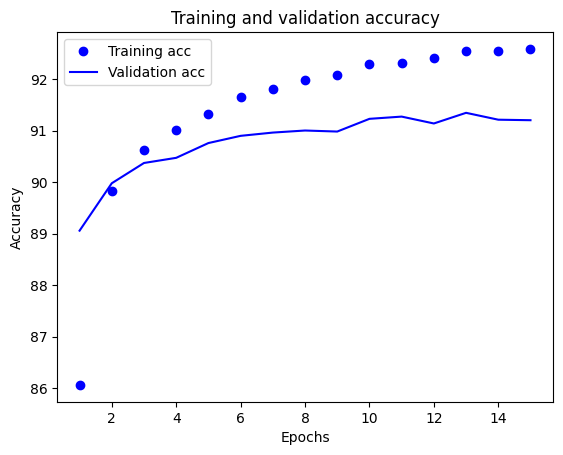

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)

In [ ]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 0.28, Test accuracy 91.95


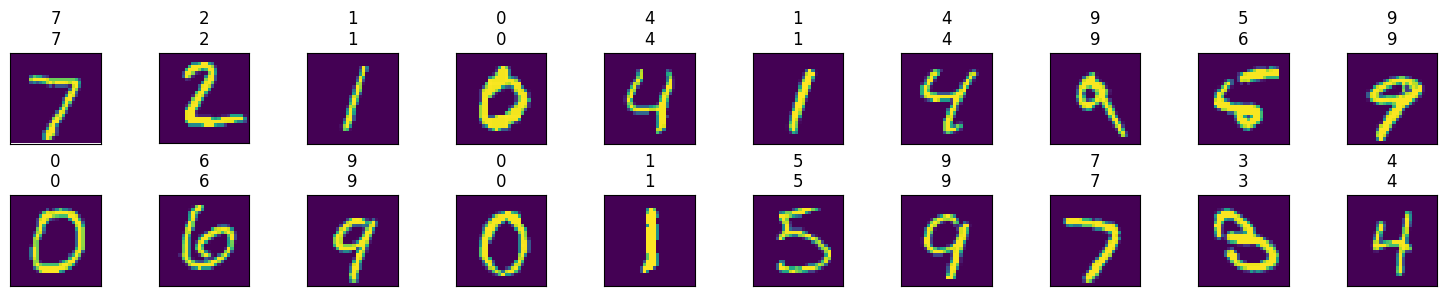

In [ ]:
def predict(net, test_iter, n=18):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter, n=20)

# Exercitiul 3

In [ ]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.MNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.MNIST(
        root="../data", train=False, transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [45000, 15000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
batch_size = 512
train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size)

In [ ]:
dropout = .4

net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.Tanh(),
        nn.Dropout(dropout),
        nn.Linear(256, 256),
        nn.Tanh(),
        nn.Dropout(dropout),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Tanh()
  (6): Dropout(p=0.4, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

In [ ]:
print(net)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Tanh()
  (6): Dropout(p=0.4, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)


In [ ]:
loss = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.SGD(net.parameters(), lr=0.15)

In [ ]:
num_epochs = 10
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

Epoch 1, Train loss 0.71, Train accuracy 78.93, Validation loss 0.38, Validation accuracy 89.15
Epoch 2, Train loss 0.41, Train accuracy 87.72, Validation loss 0.34, Validation accuracy 90.37
Epoch 3, Train loss 0.37, Train accuracy 88.96, Validation loss 0.31, Validation accuracy 91.03
Epoch 4, Train loss 0.35, Train accuracy 89.76, Validation loss 0.30, Validation accuracy 91.33
Epoch 5, Train loss 0.34, Train accuracy 90.14, Validation loss 0.30, Validation accuracy 91.28
Epoch 6, Train loss 0.32, Train accuracy 90.43, Validation loss 0.29, Validation accuracy 91.49
Epoch 7, Train loss 0.32, Train accuracy 90.63, Validation loss 0.28, Validation accuracy 91.91
Epoch 8, Train loss 0.31, Train accuracy 90.95, Validation loss 0.28, Validation accuracy 91.97
Epoch 9, Train loss 0.31, Train accuracy 90.98, Validation loss 0.27, Validation accuracy 92.20
Epoch 10, Train loss 0.29, Train accuracy 91.22, Validation loss 0.26, Validation accuracy 92.39


In [ ]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}%')

Test loss 0.25, Test accuracy 93.06%
